In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/HistoricalQuotes.csv")
df.head()

,Date,Close/Last,Volume,Open,High,Low
0,02/28/2020,$273.36,106721200,$257.26,$278.41,$256.37
1,02/27/2020,$273.52,80151380,$281.1,$286,$272.96
2,02/26/2020,$292.65,49678430,$286.53,$297.88,$286.5
3,02/25/2020,$288.08,57668360,$300.95,$302.53,$286.13
4,02/24/2020,$298.18,55548830,$297.26,$304.18,$289.23


In [6]:
df.columns = df.columns.str.strip()

# **Data Preprocessing**

In [7]:
if df.index.name == 'Date':
    df.reset_index(inplace=True)

df.columns = df.columns.str.strip()

# Convert 'Date' to datetime and set as index if 'Date' column exists.
# If 'Date' is already the index and not a column, this block will be skipped.
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)

# Process 'Close/Last' if it still exists. Otherwise, it implies it's already been renamed to 'Close'.
if 'Close/Last' in df.columns:
    df['Close/Last'] = df['Close/Last'].replace('[$,]', '', regex=True).astype(float)
    df.rename(columns={'Close/Last':'Close'}, inplace=True)

# Ensure 'Open', 'High', 'Low' are float type, removing '$' and ',' if present.
# This loop handles cases where these columns might still be object type from a fresh CSV read.
for col in ['Open', 'High', 'Low']:
    if col in df.columns and df[col].dtype == 'object':
        df[col] = df[col].replace('[$,]', '', regex=True).astype(float)

df.head()

,Close,Volume,Open,High,Low
Date,,,,,
2020-02-28,273.36,106721200,257.26,278.41,256.37
2020-02-27,273.52,80151380,281.10,286.00,272.96
2020-02-26,292.65,49678430,286.53,297.88,286.50
2020-02-25,288.08,57668360,300.95,302.53,286.13
2020-02-24,298.18,55548830,297.26,304.18,289.23


# **Check Missing Values**

In [8]:
print(df.isnull().sum())

Close     0
Volume    0
Open      0
High      0
Low       0
dtype: int64


# **Outlier Detection (IQR Method)**

In [9]:
Q1 = df['Close'].quantile(0.25)
Q3 = df['Close'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = df[(df['Close'] < lower) | (df['Close'] > upper)]
print("Outliers:", len(outliers))

Outliers: 42


In [10]:
mean_value = df['Close'].mean()

df['Close'] = np.where(df['Close'] > upper, mean_value, df['Close'])
df['Close'] = np.where(df['Close'] < lower, mean_value, df['Close'])

# **EDA**

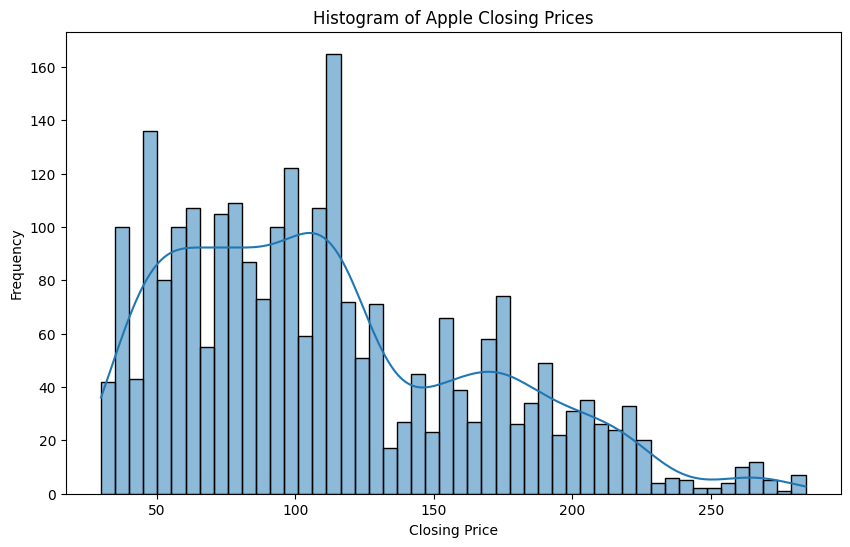

In [11]:
plt.figure(figsize=(10,6))

sns.histplot(df['Close'], bins=50, kde=True)

plt.title("Histogram of Apple Closing Prices")
plt.xlabel("Closing Price")
plt.ylabel("Frequency")

plt.show()

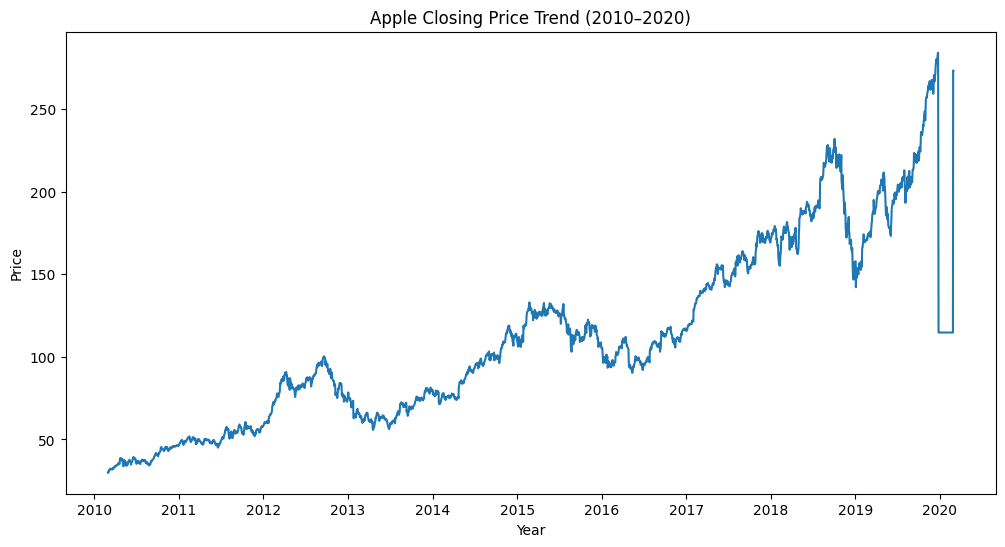

In [12]:
#Closing Price Trend
plt.figure(figsize=(12,6))

plt.plot(df['Close'])

plt.title("Apple Closing Price Trend (2010–2020)")
plt.xlabel("Year")
plt.ylabel("Price")

plt.show()

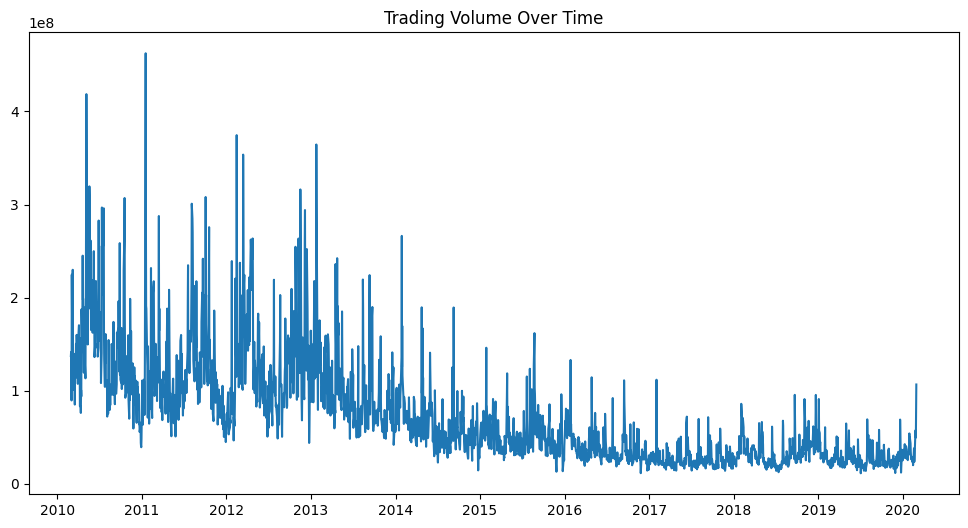

In [13]:
#Trading Volume
plt.figure(figsize=(12,6))

plt.plot(df['Volume'])

plt.title("Trading Volume Over Time")

plt.show()

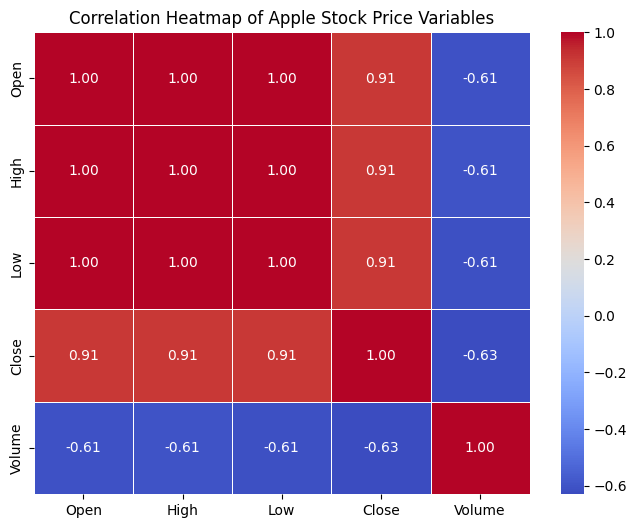

In [14]:
# Select price-related columns
price_data = df[['Open', 'High', 'Low', 'Close', 'Volume']]

# Calculate correlation matrix
corr_matrix = price_data.corr()

# Plot heatmap
plt.figure(figsize=(8,6))

sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5)

plt.title("Correlation Heatmap of Apple Stock Price Variables")

plt.show()

# **Time Series Decomposition**

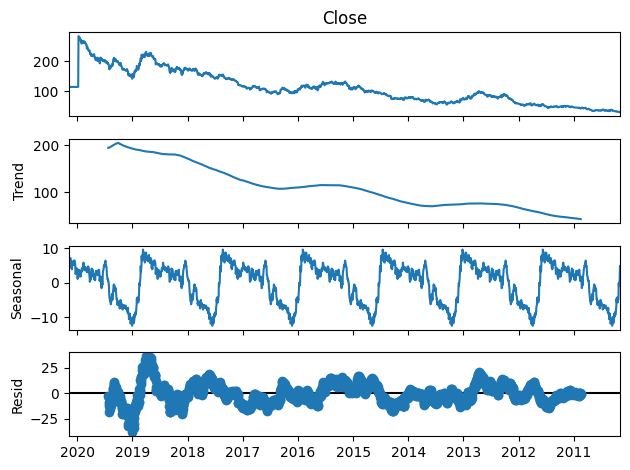

In [15]:
decomposition = seasonal_decompose(df['Close'], model='additive', period=365)

decomposition.plot()

plt.show()

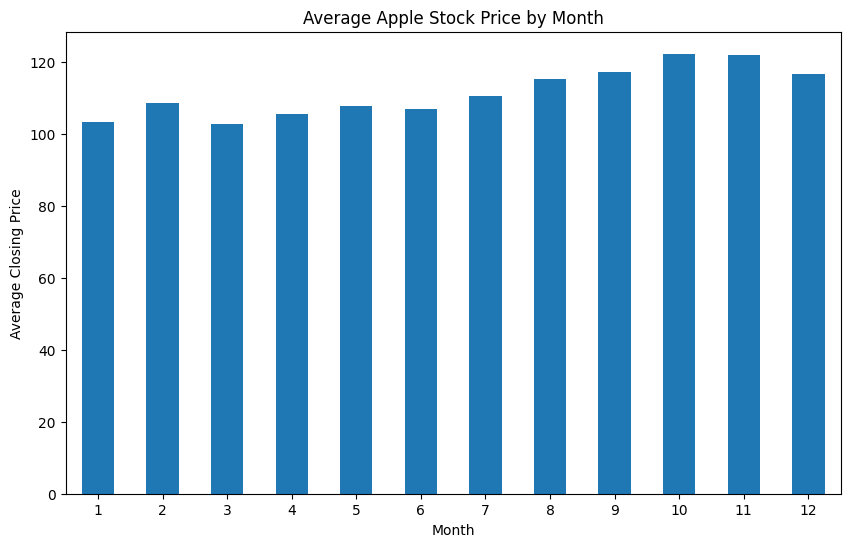

In [16]:
df['Month'] = df.index.month

monthly_pattern = df.groupby('Month')['Close'].mean()

plt.figure(figsize=(10,6))
monthly_pattern.plot(kind='bar')
plt.title("Average Apple Stock Price by Month")
plt.xlabel("Month")
plt.ylabel("Average Closing Price")
plt.xticks(rotation=0)
plt.show()

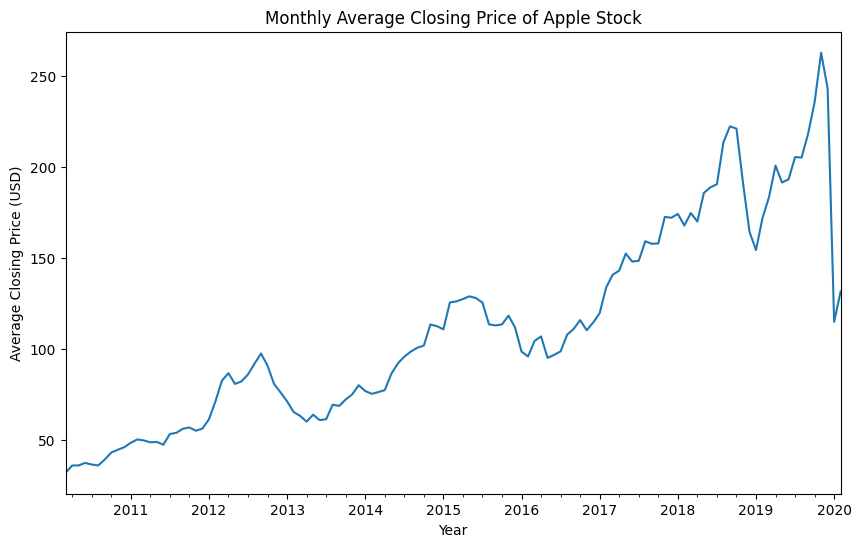

In [17]:
monthly_avg = df['Close'].resample('M').mean()

plt.figure(figsize=(10,6))
monthly_avg.plot()
plt.title("Monthly Average Closing Price of Apple Stock")
plt.xlabel("Year")
plt.ylabel("Average Closing Price (USD)")
plt.show()

# **Create Time Variables for Regression**

In [18]:
df['Time'] = np.arange(len(df))
df['Month'] = df.index.month
df['Day'] = df.index.day

df.head()

,Close,Volume,Open,High,Low,Month,Time,Day
Date,,,,,,,,
2020-02-28,273.360000,106721200,257.26,278.41,256.37,2,0,28
2020-02-27,273.520000,80151380,281.10,286.00,272.96,2,1,27
2020-02-26,114.769522,49678430,286.53,297.88,286.50,2,2,26
2020-02-25,114.769522,57668360,300.95,302.53,286.13,2,3,25
2020-02-24,114.769522,55548830,297.26,304.18,289.23,2,4,24


# **Stationarity Test (ADF Test)**

In [19]:
result = adfuller(df['Close'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:", result[4])



ADF Statistic: -3.0004009966855323
p-value: 0.034856969196035065
Critical Values: {'1%': np.float64(-3.4329507078222634), '5%': np.float64(-2.8626889823128554), '10%': np.float64(-2.567381647203466)}


In [20]:
result_diff = adfuller(df['Close'].diff().dropna())

print("ADF Statistic:", result_diff[0])
print("p-value:", result_diff[1])
print("Critical Values:", result_diff[4])

ADF Statistic: -46.547954126002125
p-value: 0.0
Critical Values: {'1%': np.float64(-3.4329527780962255), '5%': np.float64(-2.8626898965523724), '10%': np.float64(-2.567382133955709)}


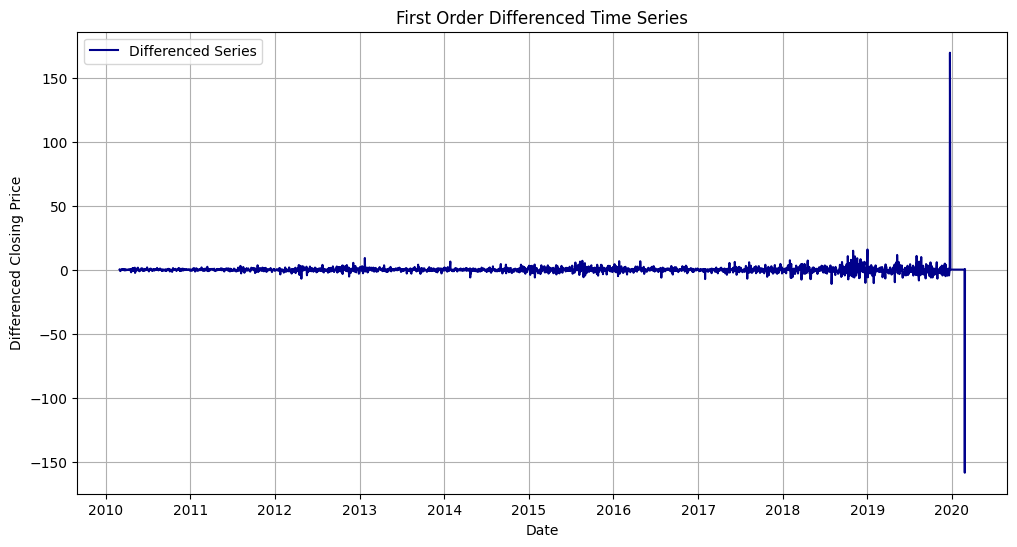

In [21]:
df['Close_diff'] = df['Close'].diff()
plt.figure(figsize=(12,6))

plt.plot(df.index, df['Close_diff'], label="Differenced Series", color='darkblue')

plt.title("First Order Differenced Time Series")
plt.xlabel("Date")
plt.ylabel("Differenced Closing Price")

plt.legend()
plt.grid(True)

plt.show()

# **Linear Regression**

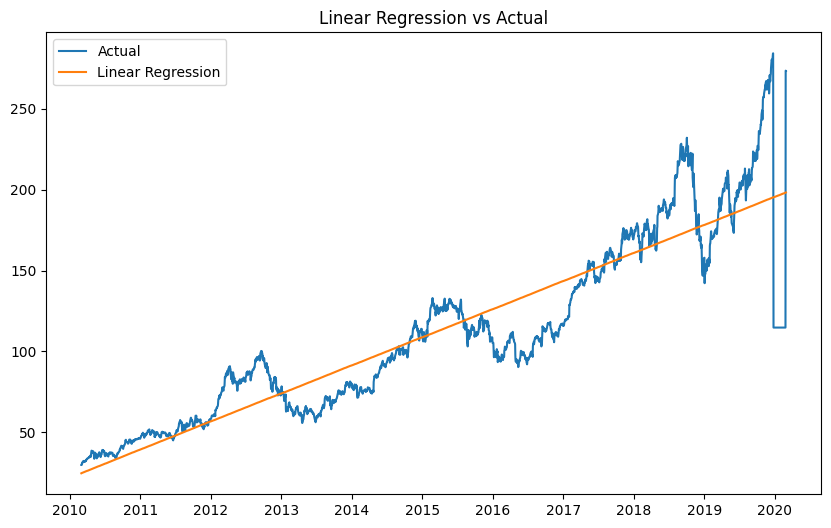

In [22]:
X = df[['Time']]
y = df['Close']

model = LinearRegression()
model.fit(X, y)

prediction = model.predict(X)

prediction = pd.Series(prediction, index=df.index)

plt.figure(figsize=(10,6))
plt.plot(df['Close'], label="Actual")
plt.plot(prediction, label="Linear Regression")
plt.legend()
plt.title("Linear Regression vs Actual")
plt.show()

# **Polynomial Regression**

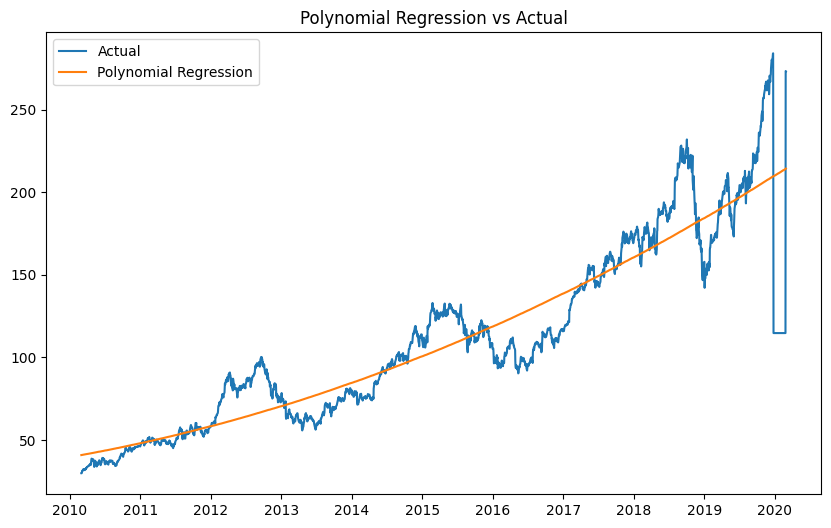

In [23]:
poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X)

poly_model = LinearRegression()
poly_model.fit(X_poly, y)

prediction_poly = poly_model.predict(X_poly)

prediction_poly = pd.Series(prediction_poly, index=df.index)

plt.figure(figsize=(10,6))
plt.plot(df['Close'], label="Actual")
plt.plot(prediction_poly, label="Polynomial Regression")

plt.legend()
plt.title("Polynomial Regression vs Actual")
plt.show()

# **Multiple Linear Regression**

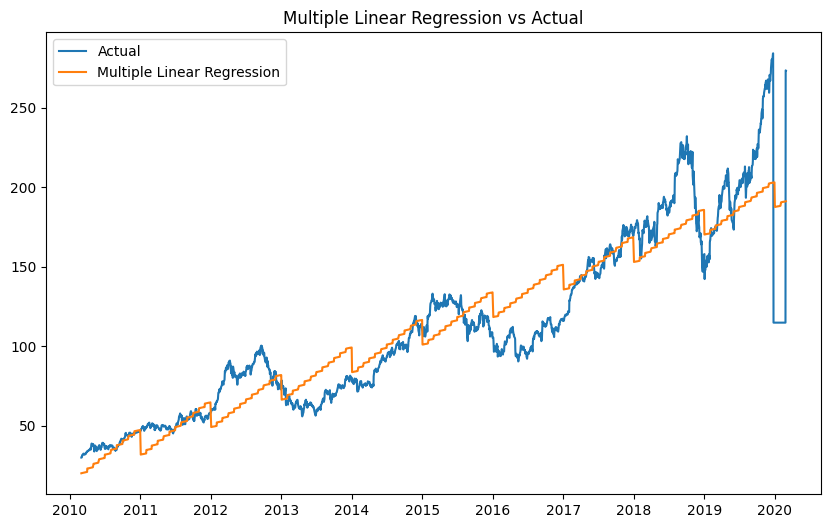

In [24]:
X_multi = df[['Time','Month','Day']]
y = df['Close']

multi_model = LinearRegression()
multi_model.fit(X_multi, y)

prediction_multi = multi_model.predict(X_multi)

prediction_multi = pd.Series(prediction_multi, index=df.index)

plt.figure(figsize=(10,6))
plt.plot(df['Close'], label="Actual")
plt.plot(prediction_multi, label="Multiple Linear Regression")

plt.legend()
plt.title("Multiple Linear Regression vs Actual")
plt.show()

# **ARIMA Model**

<Figure size 1000x600 with 0 Axes>

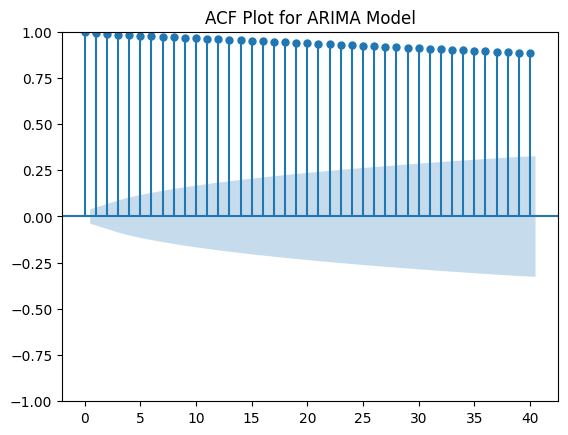

In [25]:
#ACF Plot
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10,6))
plot_acf(df['Close'], lags=40)
plt.title("ACF Plot for ARIMA Model")
plt.show()

<Figure size 1000x600 with 0 Axes>

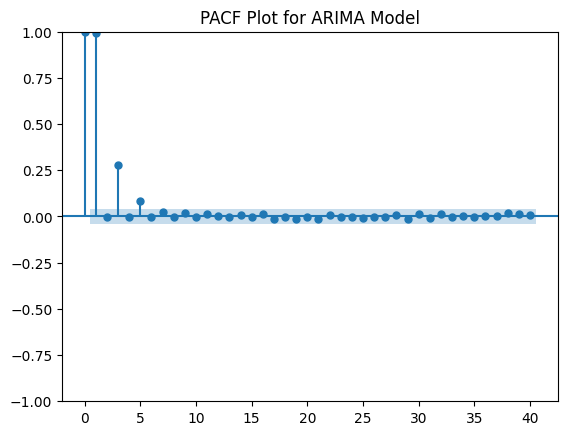

In [26]:
#PACF Plot
from statsmodels.graphics.tsaplots import plot_pacf
plt.figure(figsize=(10,6))
plot_pacf(df['Close'], lags=40)
plt.title("PACF Plot for ARIMA Model")
plt.show()

In [27]:
model_arima = ARIMA(df['Close'], order=(1,1,1))
result_arima = model_arima.fit()
print(result_arima.summary())

forecast = result_arima.forecast(steps=30)
print(forecast)

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2518
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -7629.668
Date:                Sun, 08 Mar 2026   AIC                          15265.336
Time:                        16:10:26   BIC                          15282.828
Sample:                             0   HQIC                         15271.684
                               - 2518                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0049     30.903      0.000      1.000     -60.564      60.574
ma.L1         -0.0040     30.903     -0.000      1.000     -60.573      60.565
sigma2        25.1436      0.033    758.573      0.0

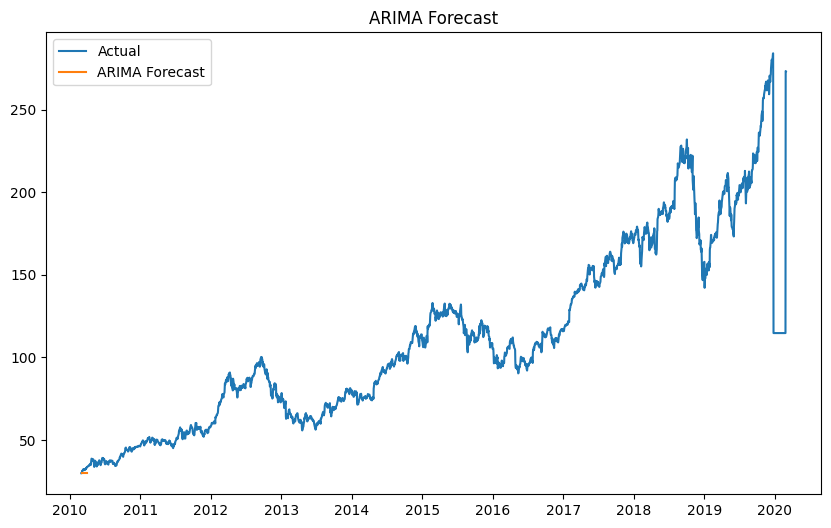

In [28]:
future_dates = pd.date_range(start=df.index[-1], periods=31, freq='D')[1:]

forecast = pd.Series(forecast.values, index=future_dates)

plt.figure(figsize=(10,6))

plt.plot(df['Close'], label="Actual")
plt.plot(forecast, label="ARIMA Forecast")

plt.legend()
plt.title("ARIMA Forecast")
plt.show()

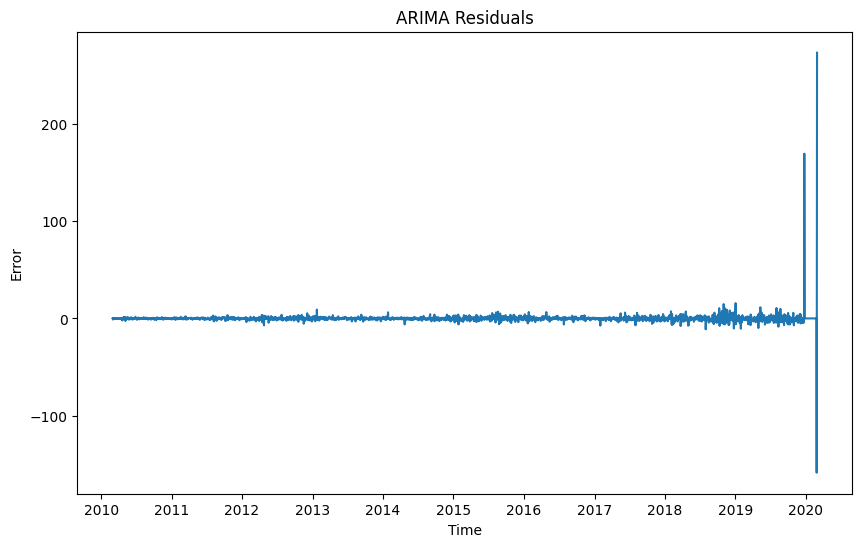

In [29]:
#ARIMA Residual Plot
residuals = result_arima.resid

plt.figure(figsize=(10,6))
plt.plot(residuals)
plt.title("ARIMA Residuals")
plt.xlabel("Time")
plt.ylabel("Error")
plt.show()

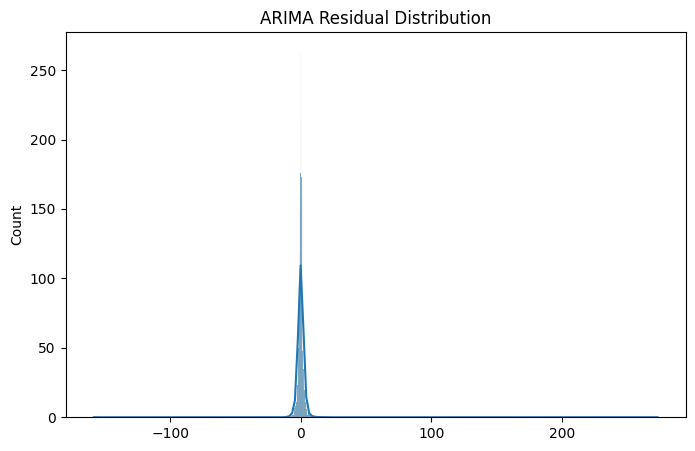

In [30]:
#Residual Distribution Plot
plt.figure(figsize=(8,5))
sns.histplot(residuals, kde=True)

plt.title("ARIMA Residual Distribution")
plt.show()

# **SARIMA Model**

In [31]:
model_sarima = SARIMAX(df['Close'],
                        order=(1,1,1),
                        seasonal_order=(1,1,1,12))
result_sarima = model_sarima.fit()

forecast_sarima = result_sarima.forecast(steps=30)
print(forecast_sarima)

2518    29.860111
2519    29.806459
2520    29.756414
2521    29.786676
2522    29.921590
2523    29.855902
2524    29.869971
2525    29.791371
2526    29.619036
2527    29.385370
2528    29.258302
2529    29.028393
2530    29.029332
2531    28.977884
2532    28.931775
2533    28.960779
2534    29.092035
2535    29.024356
2536    29.030759
2537    28.953132
2538    28.767862
2539    28.534751
2540    28.408369
2541    28.181682
2542    28.182640
2543    28.131180
2544    28.085010
2545    28.114037
2546    28.245336
2547    28.177685
Name: predicted_mean, dtype: float64


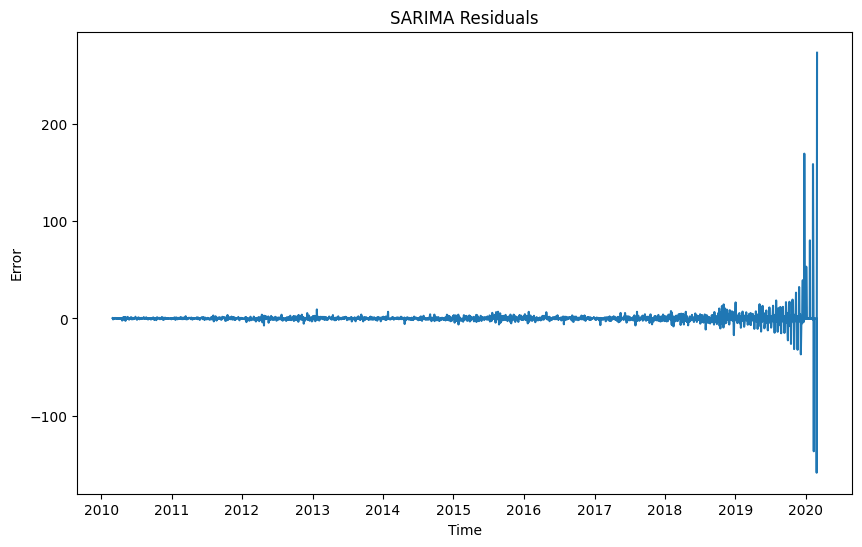

In [32]:
#SARIMA Residual Plot
residuals_sarima = result_sarima.resid

plt.figure(figsize=(10,6))
plt.plot(residuals_sarima)

plt.title("SARIMA Residuals")
plt.xlabel("Time")
plt.ylabel("Error")

plt.show()

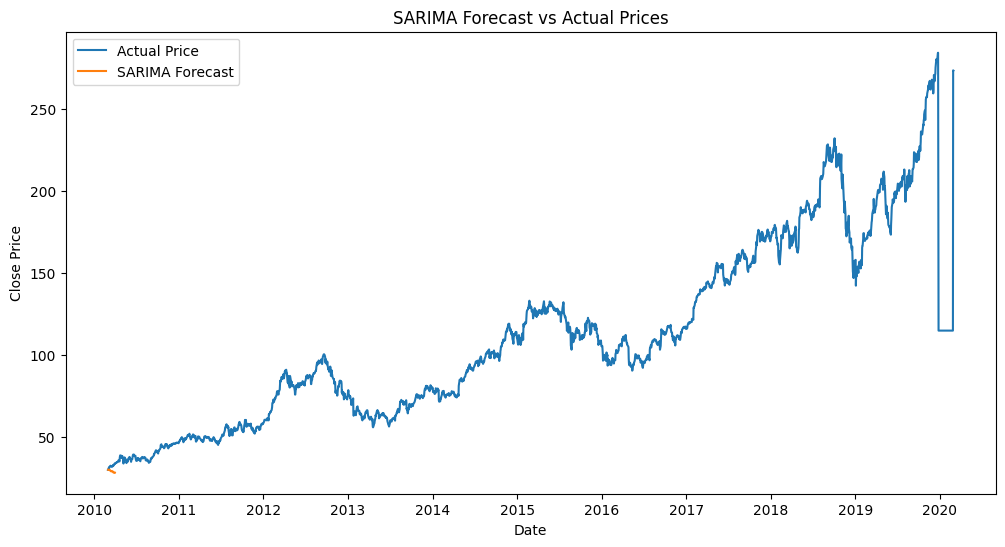

In [33]:
# plt.figure(figsize=(12,6))

# plt.plot(df['Close'], label='Actual Price')

# plt.plot(range(len(df), len(df)+30),
#          forecast_sarima,
#          label='SARIMA Forecast')

# plt.title("SARIMA Forecast vs Actual Prices")
# plt.xlabel("Time")
# plt.ylabel("Close Price")
# plt.legend()

# plt.show()

forecast_sarima = result_sarima.forecast(steps=30)

future_dates = pd.date_range(start=df.index[-1], periods=31, freq='D')[1:]

forecast_sarima = pd.Series(forecast_sarima.values, index=future_dates)

plt.figure(figsize=(12,6))

plt.plot(df['Close'], label="Actual Price")
plt.plot(forecast_sarima, label="SARIMA Forecast")

plt.title("SARIMA Forecast vs Actual Prices")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()

plt.show()

# **Model Evaluation**

In [34]:
train_size = int(len(df) * 0.8)
train = df['Close'].iloc[:train_size]
test = df['Close'].iloc[train_size:]

## **Make Forecasts for Test Period**

In [35]:
#Linear Regression (Time only)
X_train = np.arange(len(train)).reshape(-1,1)
X_test = np.arange(len(train), len(df)).reshape(-1,1)

lr_model = LinearRegression()
lr_model.fit(X_train, train)

lr_pred = lr_model.predict(X_test)

In [36]:
#Polynomial Regression (Degree=2)
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, train)

poly_pred = poly_model.predict(X_test_poly)

In [37]:
#Multiple Linear Regression (Time + Month + Day)
X_train_multi = df[['Time','Month','Day']].iloc[:train_size]
X_test_multi = df[['Time','Month','Day']].iloc[train_size:]

multi_model = LinearRegression()
multi_model.fit(X_train_multi, train)

multi_pred = multi_model.predict(X_test_multi)

In [38]:
#ARIMA
model_arima = ARIMA(train, order=(1,1,1))
result_arima = model_arima.fit()
arima_pred = result_arima.forecast(steps=len(test))

In [39]:
#SARIMA
model_sarima = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12))
result_sarima = model_sarima.fit()
sarima_pred = result_sarima.forecast(steps=len(test))

## **Evaluate Models with Metrics**

In [40]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import numpy as np

def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)*100
    print(f"{model_name} --> RMSE: {rmse:.2f}, MAE: {mae:.2f}, MAPE: {mape:.2f}%")

# Evaluate
evaluate_model(test, lr_pred, "Linear Regression")
evaluate_model(test, poly_pred, "Polynomial Regression")
evaluate_model(test, multi_pred, "Multiple Linear Regression")
evaluate_model(test, arima_pred, "ARIMA")
evaluate_model(test, sarima_pred, "SARIMA")

Linear Regression --> RMSE: 13.38, MAE: 12.90, MAPE: 28.85%
Polynomial Regression --> RMSE: 23.25, MAE: 21.69, MAPE: 51.33%
Multiple Linear Regression --> RMSE: 15.09, MAE: 12.99, MAPE: 28.99%
ARIMA --> RMSE: 30.61, MAE: 29.17, MAPE: 68.11%
SARIMA --> RMSE: 23.99, MAE: 23.21, MAPE: 53.54%


## **Visual Comparison**

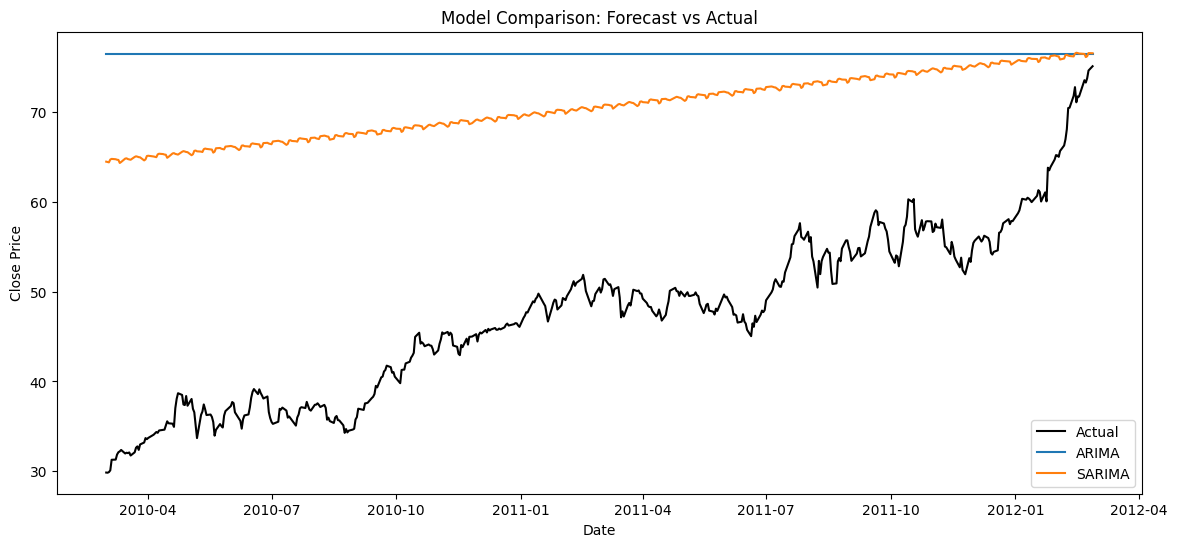

In [41]:
plt.figure(figsize=(14,6))
plt.plot(test.index, test, label="Actual", color='black')

plt.plot(test.index, arima_pred, label="ARIMA")
plt.plot(test.index, sarima_pred, label="SARIMA")

plt.title("Model Comparison: Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.show()

# **future forecasting with SARIMA**

In [42]:
#Fit the SARIMA Model

model_sarima = SARIMAX(df['Close'],
                       order=(1,1,1),
                       seasonal_order=(1,1,1,12))
sarima_fit = model_sarima.fit()
print(sarima_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Close   No. Observations:                 2518
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -7614.626
Date:                            Sun, 08 Mar 2026   AIC                          15239.252
Time:                                    16:10:49   BIC                          15268.382
Sample:                                         0   HQIC                         15249.827
                                           - 2518                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6549      0.984     -0.666      0.506      -2.583       1.273
ma.L1          0.6620      0.959   

In [43]:
#Forecast Future Prices

# Forecast next 30 days
future_steps = 30
future_forecast = sarima_fit.get_forecast(steps=future_steps)

# Forecast values and confidence intervals
forecast_values = future_forecast.predicted_mean
conf_int = future_forecast.conf_int()

# Create future dates
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=future_steps, freq='D')

# Align index
forecast_values.index = future_dates
conf_int.index = future_dates

# Combine forecast and CI into a single DataFrame
forecast_df = pd.DataFrame({
    'Forecast': forecast_values,
    'Lower_CI': conf_int.iloc[:,0],
    'Upper_CI': conf_int.iloc[:,1]
})

print(forecast_df)

             Forecast   Lower_CI   Upper_CI
2010-03-02  29.860111  20.006425  39.713797
2010-03-03  29.806459  15.821672  43.791246
2010-03-04  29.756414  12.634910  46.877918
2010-03-05  29.786676  10.005083  49.568268
2010-03-06  29.921590   7.806262  52.036919
2010-03-07  29.855902   5.625366  54.086439
2010-03-08  29.869971   3.697789  56.042153
2010-03-09  29.791371   1.810008  57.772733
2010-03-10  29.619036  -0.060226  59.298298
2010-03-11  29.385370  -1.900527  60.671268
2010-03-12  29.258302  -3.555194  62.071797
2010-03-13  29.028393  -5.244975  63.301760
2010-03-14  29.029332  -6.731698  64.790363
2010-03-15  28.977884  -8.212074  66.167841
2010-03-16  28.931775  -9.633743  67.497293
2010-03-17  28.960779 -10.933188  68.854746
2010-03-18  29.092035 -12.087363  70.271433
2010-03-19  29.024356 -13.401662  71.450375
2010-03-20  29.030759 -14.606206  72.667724
2010-03-21  28.953132 -15.862118  73.768382
2010-03-22  28.767862 -17.195447  74.731171
2010-03-23  28.534751 -18.548651

In [44]:
forecast_df.to_csv("SARIMA_30day_forecast.csv")